<a href="https://colab.research.google.com/github/haorangee/-ASU-ML_Customer-Churn-Prediction/blob/main/ML_term_project_Final_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Topic:  Customer Churn Prediction

## member: Sky Lee(81481305), Soyeon Kim(81481821)

In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

import os
os.listdir()

['.config',
 'archive.zip',
 'WA_Fn-UseC_-Telco-Customer-Churn.csv',
 'sample_data']

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#1. Data Preparing

##1.1 Feature Type Analysis

All 21 features in the dataset are non-null. Based on the data, the features were categorized as follows:

1. Nominal – MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaymentMethod

2. Binary – gender, SeniorCitizen, Partner, Dependents, PhoneService, PaperlessBilling, Churn

3. Categorical (3-class) – Contract

4. Numerical (Ratio) – tenure, MonthlyCharges, TotalCharges

The customerID variable was removed because it serves only as a unique identifier (primary key) and does not provide predictive information.

Although TotalCharges was originally stored as an object type, it represents numeric values. Therefore, it was converted to a float for proper analysis.

In [ ]:
df=df.drop('customerID', axis=1) #customerID is just a pk that distinguishes data, so delete it.

object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    print(col, df[col].unique(), " -> ", len(df[col].unique()), "labels")

gender ['Female' 'Male']  ->  2 labels
Partner ['Yes' 'No']  ->  2 labels
Dependents ['No' 'Yes']  ->  2 labels
PhoneService ['No' 'Yes']  ->  2 labels
MultipleLines ['No phone service' 'No' 'Yes']  ->  3 labels
InternetService ['DSL' 'Fiber optic' 'No']  ->  3 labels
OnlineSecurity ['No' 'Yes' 'No internet service']  ->  3 labels
OnlineBackup ['Yes' 'No' 'No internet service']  ->  3 labels
DeviceProtection ['No' 'Yes' 'No internet service']  ->  3 labels
TechSupport ['No' 'Yes' 'No internet service']  ->  3 labels
StreamingTV ['No' 'Yes' 'No internet service']  ->  3 labels
StreamingMovies ['No' 'Yes' 'No internet service']  ->  3 labels
Contract ['Month-to-month' 'One year' 'Two year']  ->  3 labels
PaperlessBilling ['Yes' 'No']  ->  2 labels
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']  ->  4 labels
TotalCharges ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']  ->  6531 labels
Churn ['No' 'Yes']  ->  2 labels


In [ ]:
df["SeniorCitizen"].value_counts()
# SeniorCitizen is a binary data type, but it is an int. I will add it to object_col.

,count
SeniorCitizen,
0,5901
1,1142


In [ ]:
#TotalCharges is an object type, but it's numeric. Let's change the data type to numeric.

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].mean(), inplace=True)


/tmp/ipython-input-2241401936.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].mean(), inplace=True)


In [ ]:
object_cols = list(df.select_dtypes(include='object').columns)
object_cols.append("SeniorCitizen") #SeniorCitizen

## 1.2 Analysis of feature distribution and its relationship with churn

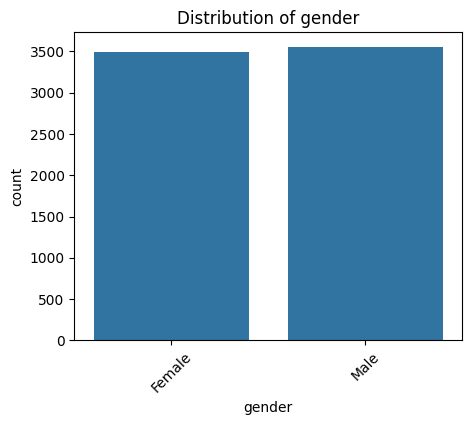

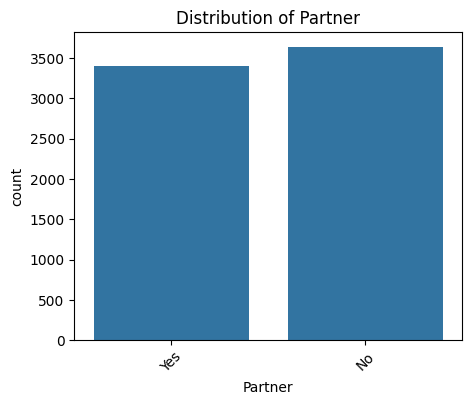

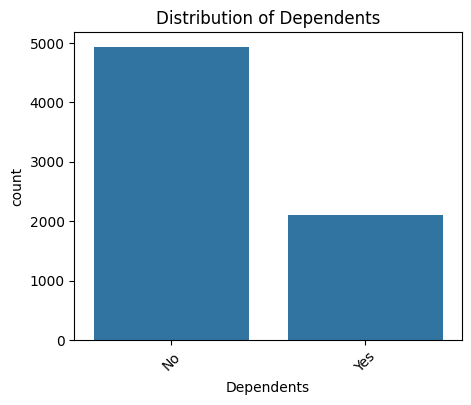

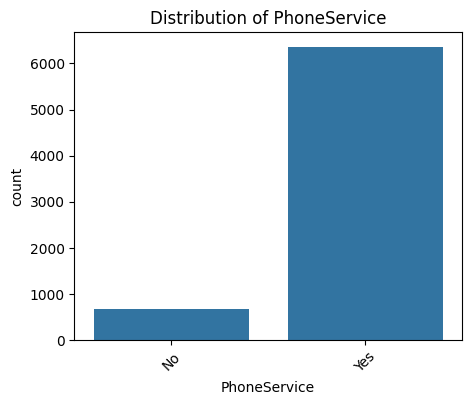

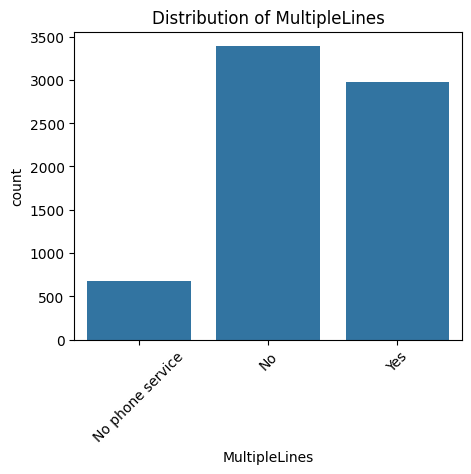

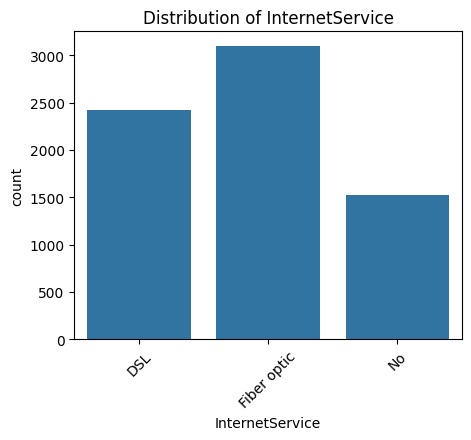

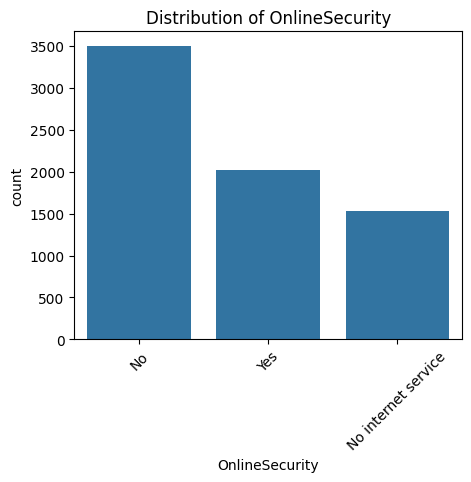

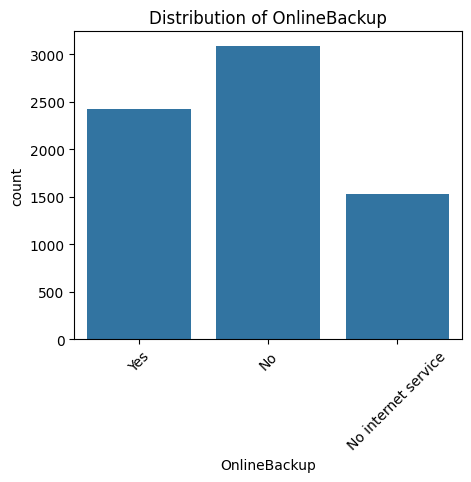

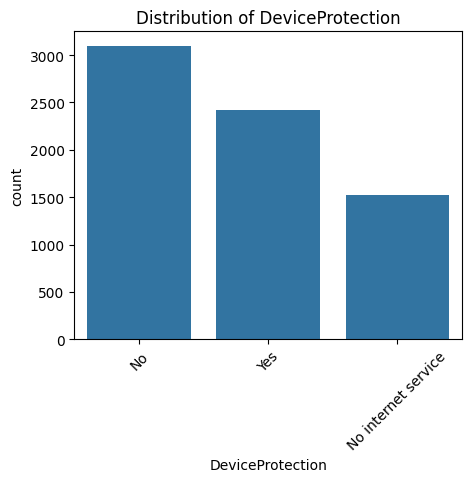

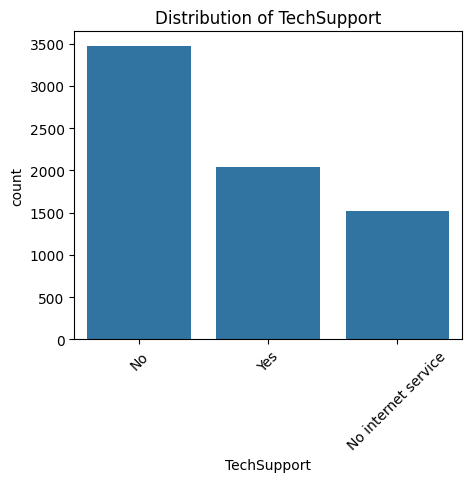

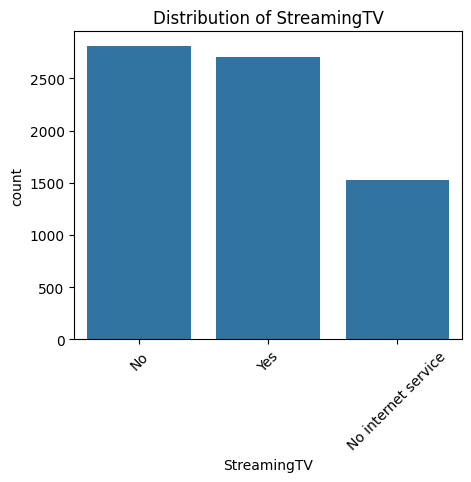

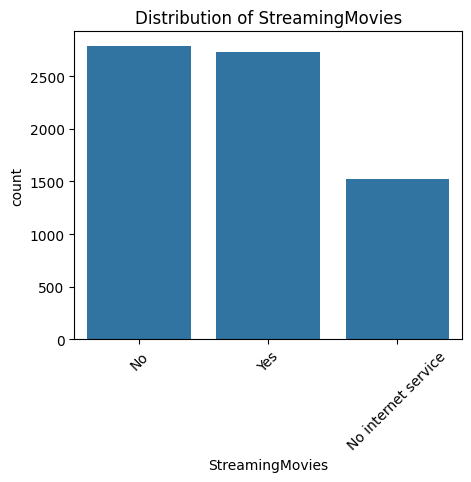

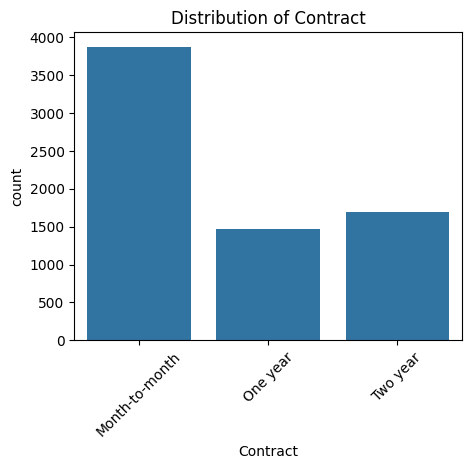

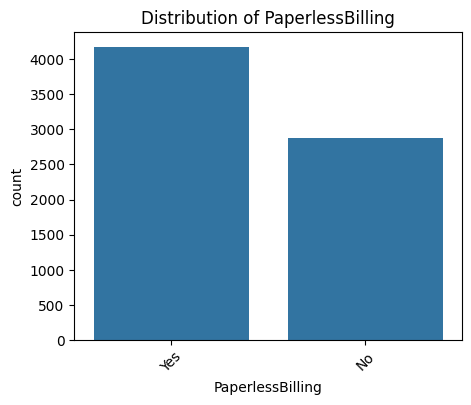

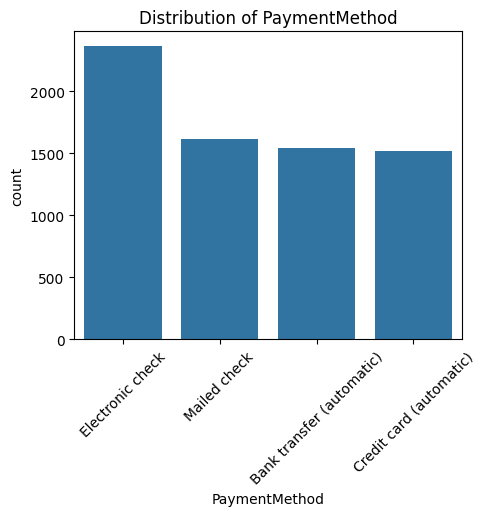

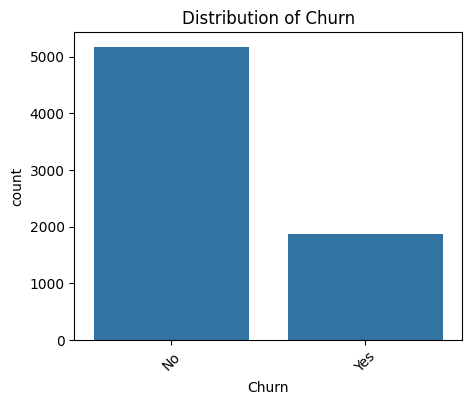

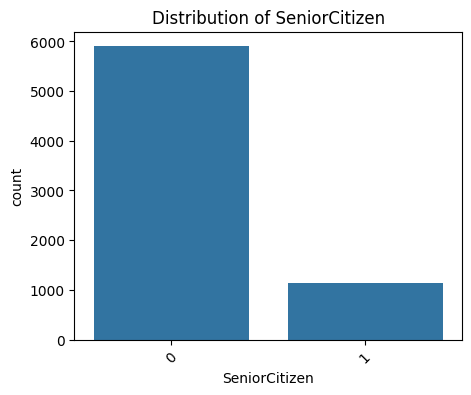

In [ ]:
# Distribution of object_cols

for col in object_cols:
  plt.figure(figsize=(5,4))
  sns.countplot(data=df, x=col)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation=45)
  plt.show()

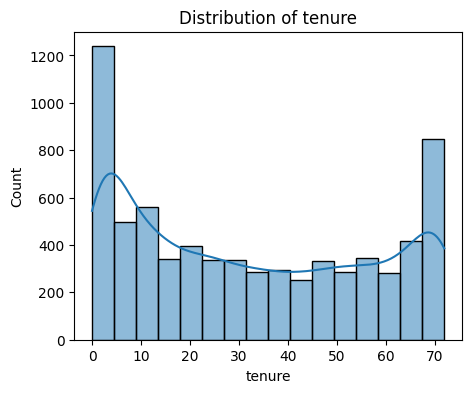

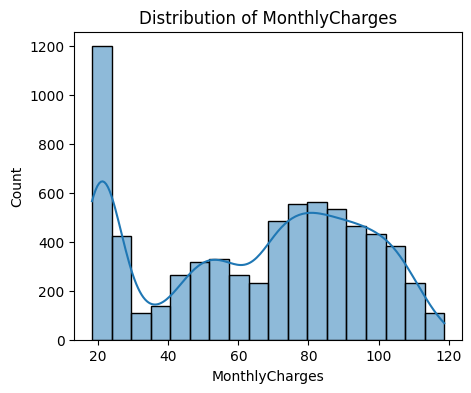

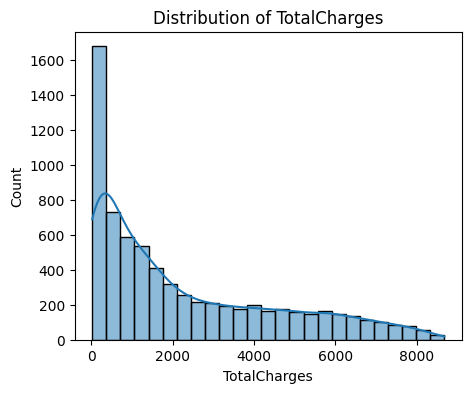

In [ ]:
# Distribution of numerical cols

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Let's find out the churn rate for each attribute.

In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

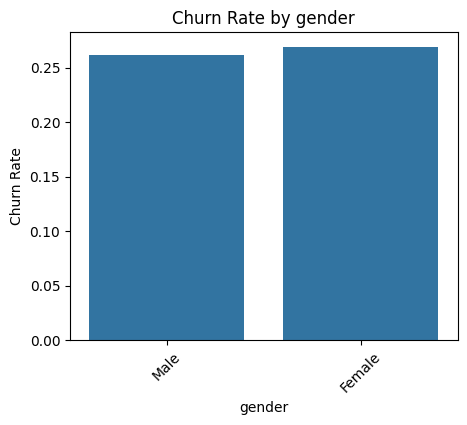

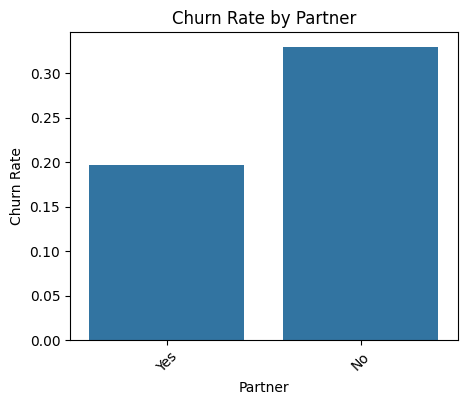

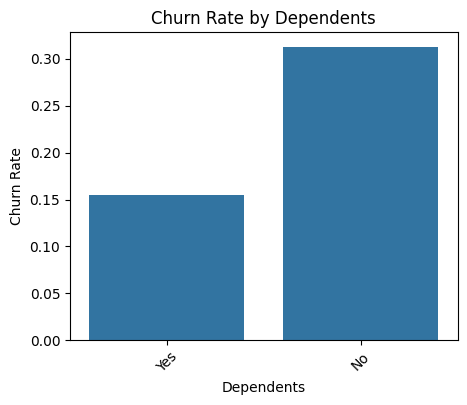

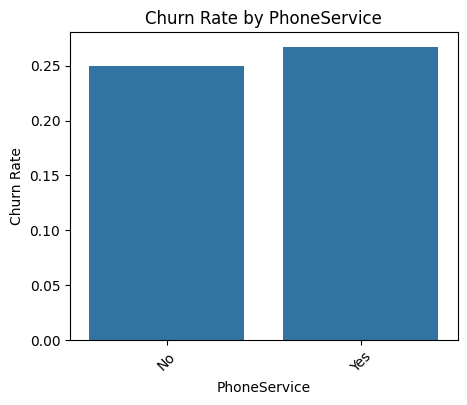

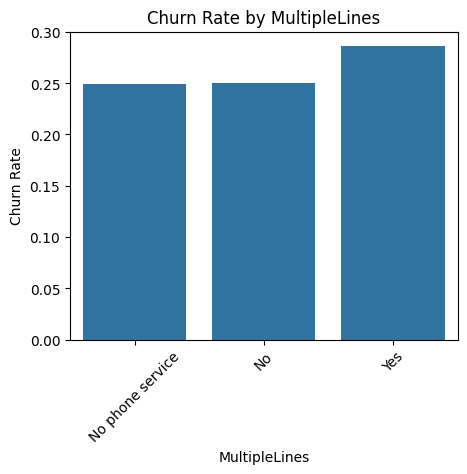

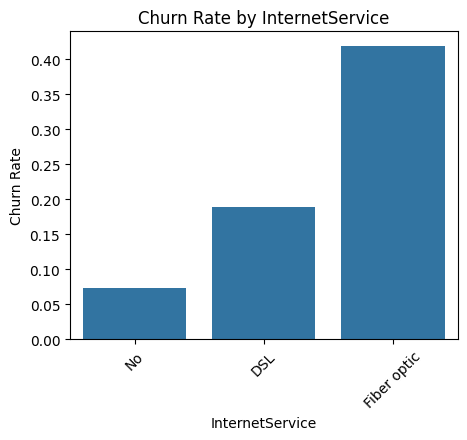

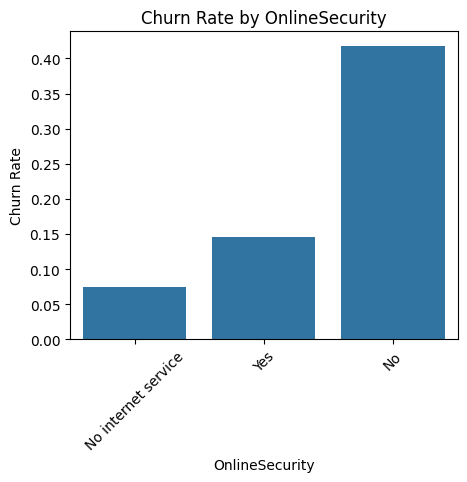

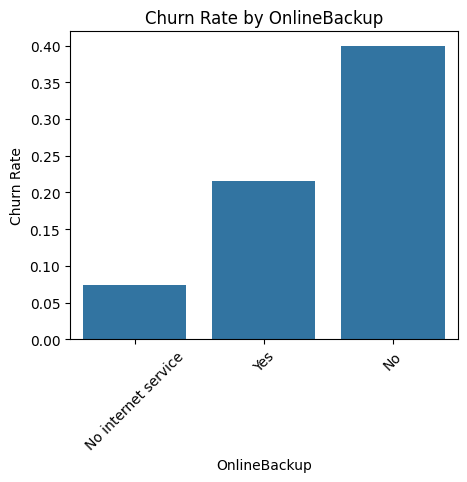

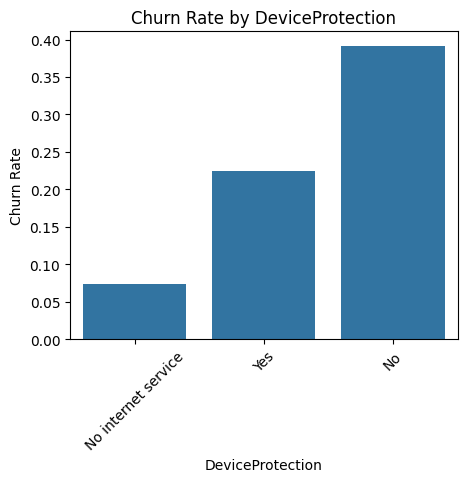

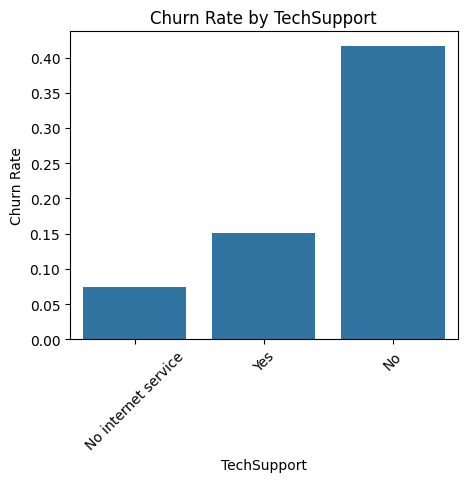

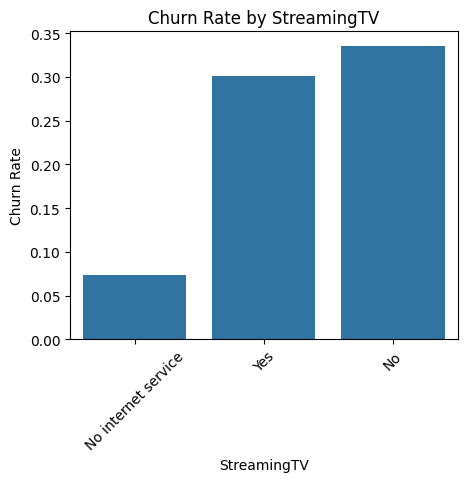

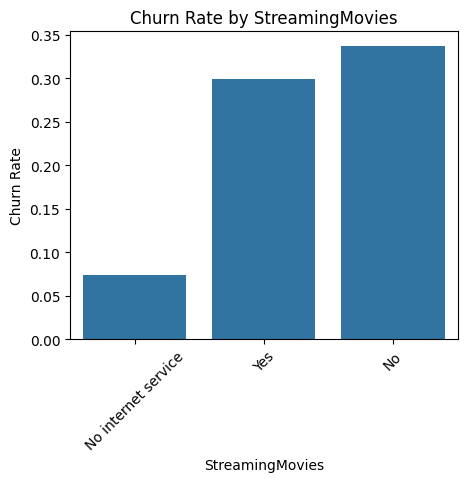

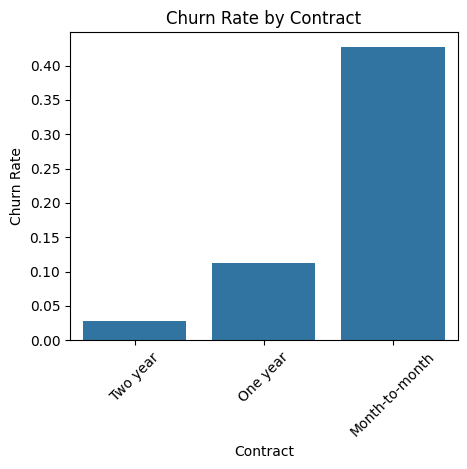

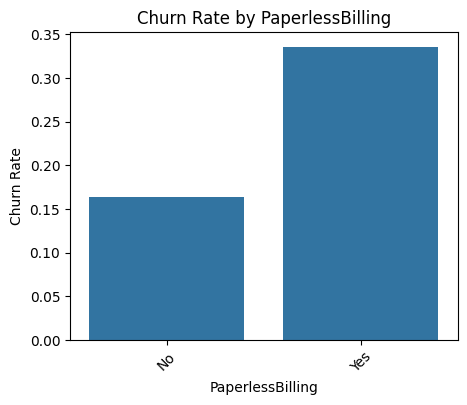

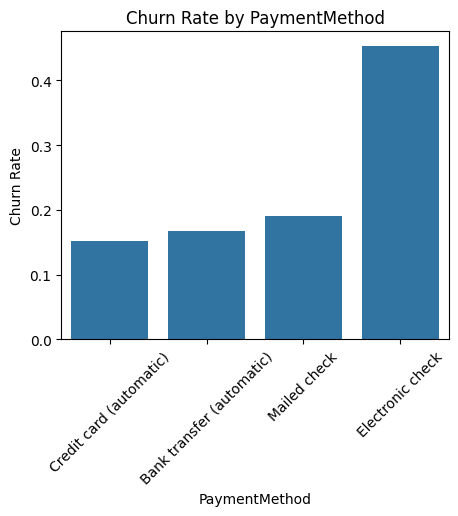

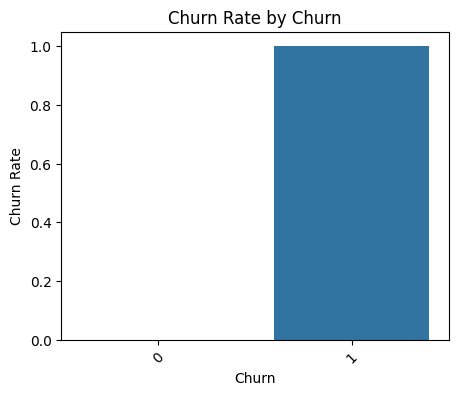

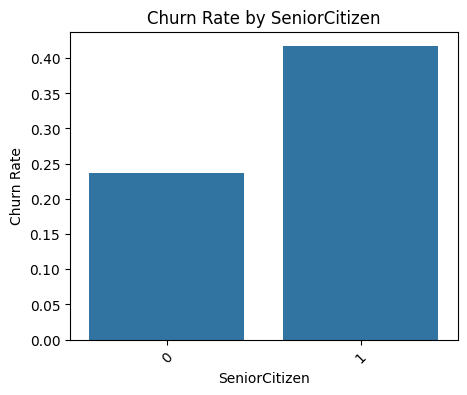

In [ ]:
for col in object_cols:
    plt.figure(figsize=(5,4))
    churn_rate = df.groupby(col)['Churn'].mean().sort_values()
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)
    plt.show()


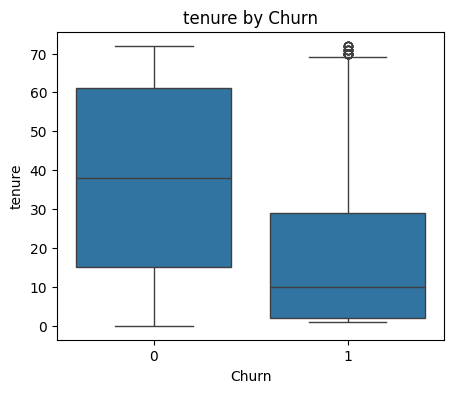

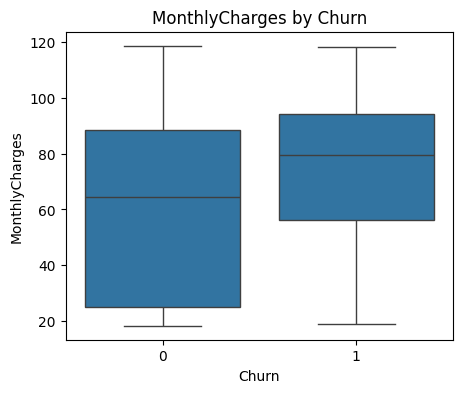

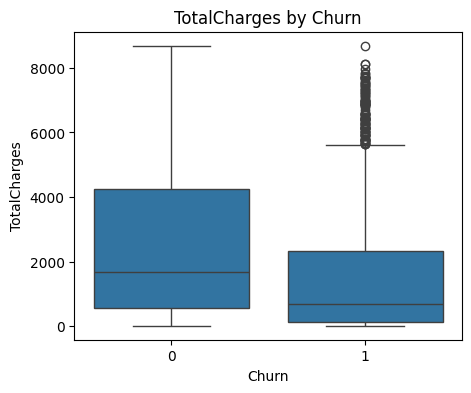

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f"{col} by Churn")
    plt.show()
  # 0: stayed, 1: churn

### Results obtained by graphing the relationship between each feature and churn:

- Contract

Month-to-month customers have a very high churn rate. Customers with 1-year and 2-year contracts have significantly lower churn rates.

- Payment Method

Electronic check customers have the highest churn rate.

- Tenure

The shorter the subscription period, the higher the churn rate. Long-term customers are very unlikely to churn.

- Monthly Charges

The higher the subscription fee, the more likely it is to churn.

- Gender, Phone Service, Multiple Lines

The churn rate by label is nearly identical, suggesting a low impact.

- Target (Churn)

Yes≈27%, No≈73%, indicating class imbalance.

Now we will do label encoding.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [ ]:
le = LabelEncoder()

for col in object_cols:
    df[col] = le.fit_transform(df[col])


tenure - outliers: 0, bound: -60.0 ~ 124.0
MonthlyCharges - outliers: 0, bound: -46.02 ~ 171.38
TotalCharges - outliers: 0, bound: -4674.34 ~ 8863.16


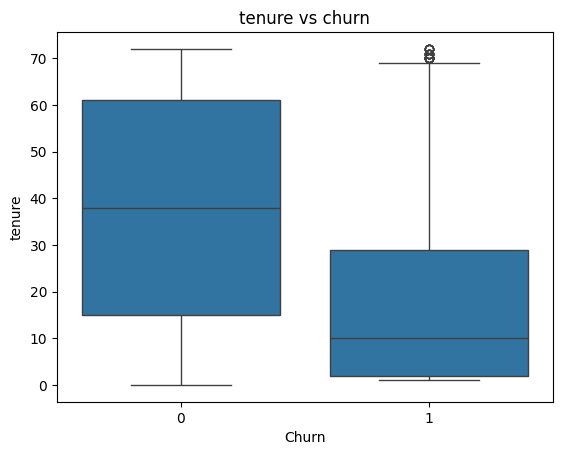

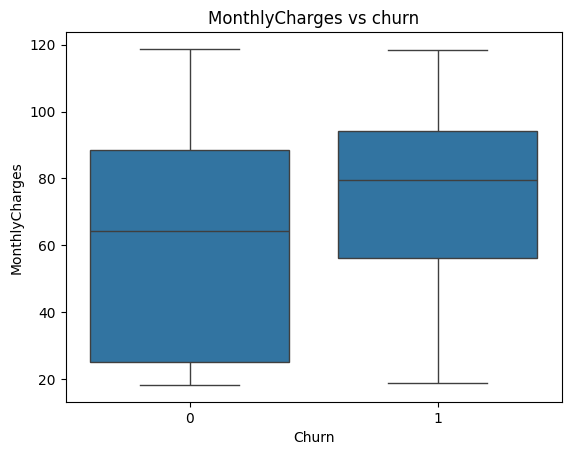

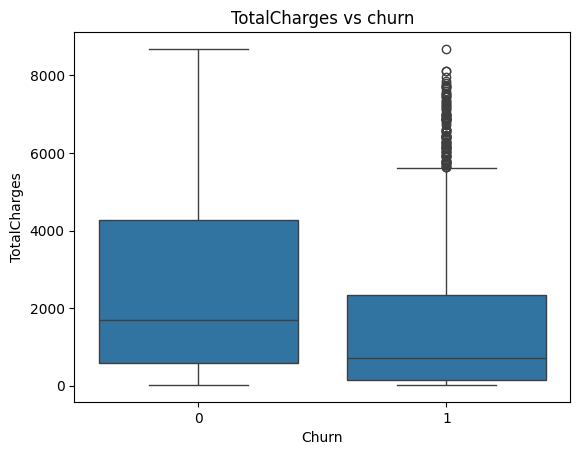

In [ ]:
# Finding outlier
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_dict[col] = {
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "num_outliers": len(outliers)
    }

for col, stats in outliers_dict.items():
    print(f"{col} - outliers: {stats['num_outliers']}, bound: {stats['lower_bound']} ~ {stats['upper_bound']}")

for col in numeric_cols:
  sns.boxplot(x='Churn', y=col, data=df)
  plt.title( col + " vs churn")
  plt.show()

  # No outlier

##1.3 Feature Correlation

In [ ]:
#Correlation between feature and churn
corr = df.corr()
churn_corr = corr["Churn"].sort_values(ascending=False)
print(churn_corr)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199428
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


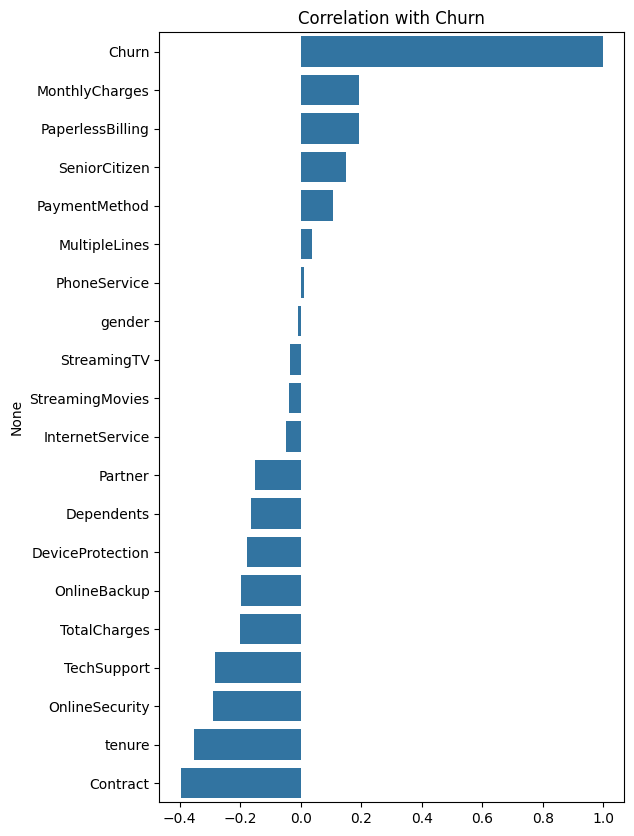

In [ ]:
plt.figure(figsize=(6,10))
sns.barplot(x=churn_corr.values, y=churn_corr.index)
plt.title("Correlation with Churn")
plt.show()

Looking at the correlation coefficients, we can see that the top five attributes with the highest correlations are Contract, Tenure, OnlineSecurity, TechSupport, and TotalSupport, while the bottom five are Gender, PhoneService, StreamingTV, MultipleLines, and StreamingMovies.

However, since correlations only reflect linear relationships and are affected by label encoding,
we will use this as a reference indicator of feature importance.

##1.4 EDA Conclusion

1. Based on the churn rate of each feature, variables such as Contract, PaymentMethod, tenure, and MonthlyCharges appear to be important factors related to customer churn. In contrast, gender and MultipleLines show very similar churn rates across categories, suggesting that they are not strongly influential.

2. Correlation analysis also indicates that Contract, tenure, OnlineSecurity, TechSupport, and TotalCharges are relatively important, while gender, PhoneService, StreamingTV, MultipleLines, and StreamingMovies show little association with churn.
However, correlation relies on numerical representations (e.g., Label Encoding) and therefore does not fully capture non-linear relationships. For this reason, correlation analysis is used only as a supplementary tool for understanding feature importance.

3. The target variable (Churn) shows class imbalance, with significantly more “No” samples than “Yes.”

4. No missing values or major outliers were found in the dataset.

Direction for Modeling

1. Since the target is binary, a classification approach will be used. Logistic Regression and Decision Tree models will serve as baseline classifiers.

2. The primary goal is to identify customers who are likely to churn; therefore, maximizing Recall for the churn class is more important than focusing solely on accuracy.

3. Some features appear unimportant from EDA, but they may still have non-linear interactions with the target. Therefore, feature removal will be tested but not assumed to improve performance.

4. Because of the class imbalance in the target variable, resampling techniques will be applied to observe how model performance changes when the dataset is balanced.

#2. Train and Test & Evaluation

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

## 2.1 Logistic Regression


In [ ]:
#Logistic Regression
log_model = LogisticRegression(max_iter=200, solver="lbfgs", random_state=42)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))


Logistic Regression Accuracy: 0.7970191625266146
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.56      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy 0.79, recall score 0.56 for class 1

##2.2 Decision Tree

In [ ]:
#Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print(classification_report(y_test, tree_pred))


Decision Tree Accuracy: 0.7849538679914834
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.60      0.55      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



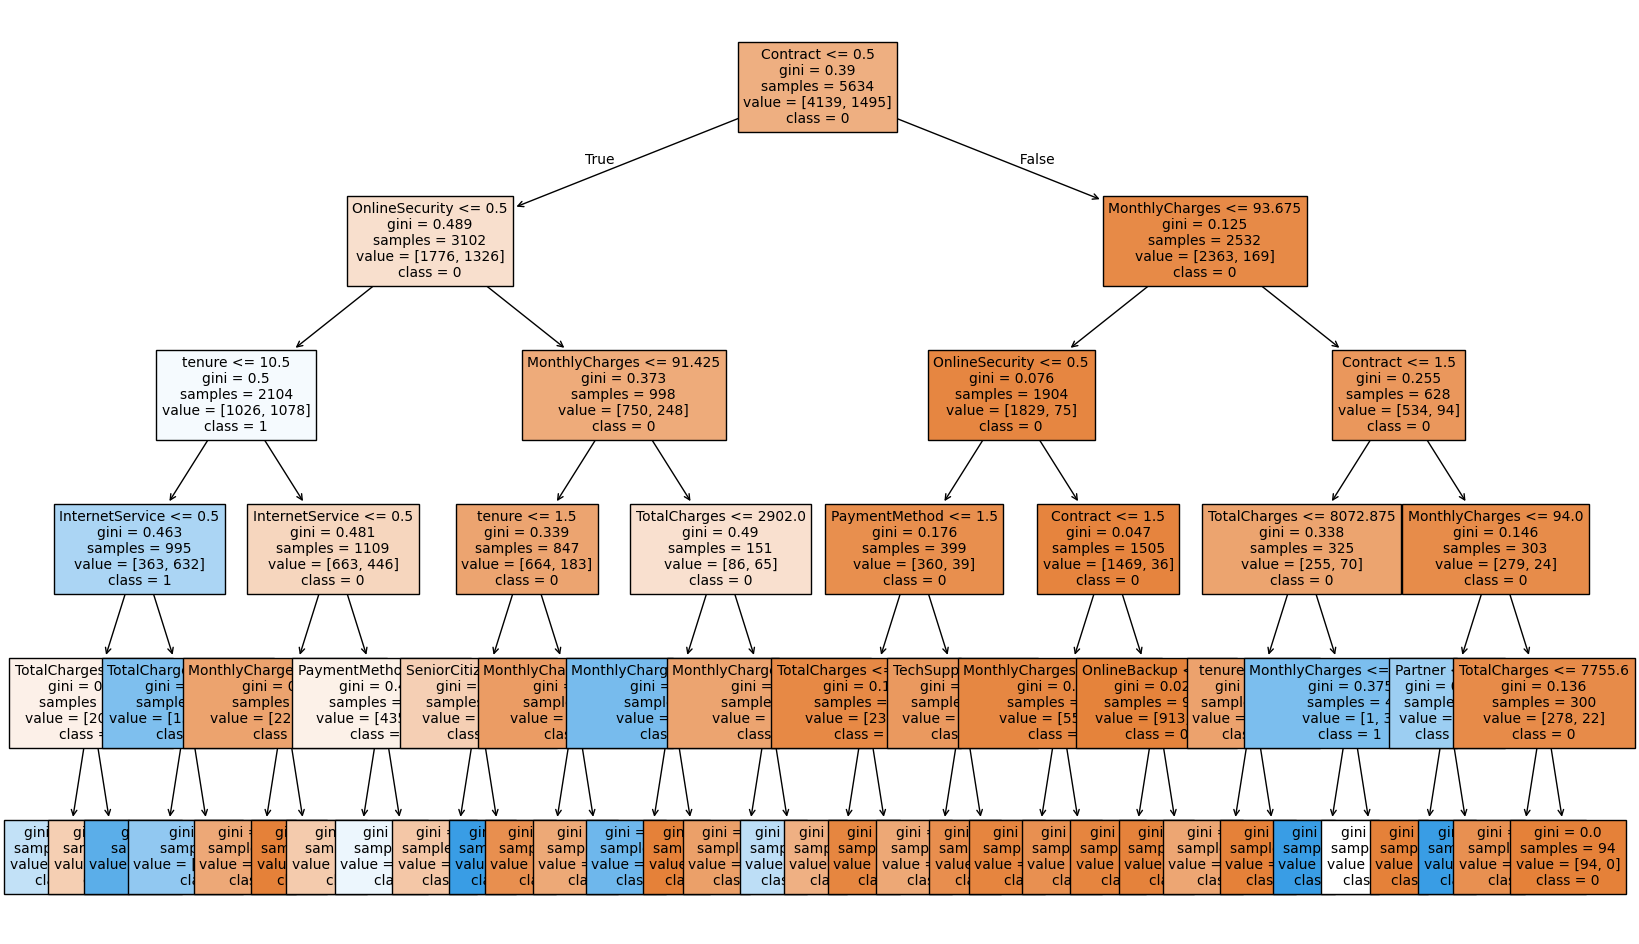

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=[str(c) for c in tree_model.classes_],
    filled=True,
    fontsize=10
)

plt.show()


Accuracy 0.78, recall score 0.55 for class 1

## 2.3 Results Analysis

- Logistic Regression
  
  The model achieved an accuracy of 0.79 and a recall of 0.56 for class 1 (Churn). Although the overall accuracy is relatively high, the low recall indicates that the model fails to identify more than half of the actual churn cases. This limitation arises because Logistic Regression is a linear model, and therefore struggles to capture the more complex, non-linear patterns present in customer churn behavior.

- Decision Tree

  The Decision Tree model performed similarly, with an accuracy of 0.78 and a recall of 0.55 for class 1. Even though Decision Trees can model non-linear relationships, the strong class imbalance causes the model to become biased toward the majority class (0), leading to underperformance in detecting churn customers.

## 2.4 Changes in results after feature selection

In [ ]:
#Remove features that were thought to have less influence
X = df.drop(["Churn", "gender", "MultipleLines", "PhoneService", "StreamingTV", "StreamingMovies"], axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
#Logistic Regression
log_model = LogisticRegression(max_iter=200, solver="lbfgs", random_state=42)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7955997161107168
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.56      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print(classification_report(y_test, tree_pred))


Decision Tree Accuracy: 0.7849538679914834
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.60      0.55      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



After removing features deemed to have low impact (e.g., gender, MultipleLines, PhoneService), and retraining the model, the performance was nearly identical to the original.

This suggests that the main features (e.g., Contract, Tenure, OnlineSecurity) account for most of the predictive power,

and that removing some low-importance features does not significantly impact performance.

Therefore, using all features is more reliable.

## 2.5 Changes in results after class imbalance is resolved

In [ ]:
# Solving class imbalance by sampling

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import Counter

under = RandomUnderSampler(sampling_strategy={0: 3500}, random_state=42)
over = SMOTE(sampling_strategy={1: 3500}, random_state=42)

resample_pipeline = Pipeline(steps=[('under', under), ('over', over)])

X_train_resampled, y_train_resampled = resample_pipeline.fit_resample(X_train, y_train)
HR2 = pd.concat([X_train_resampled, y_train_resampled], axis=1)

print("Before:", Counter(y_train))
print("After: ", Counter(y_train_resampled))

Before: Counter({0: 4139, 1: 1495})
After:  Counter({0: 3500, 1: 3500})


In [ ]:
#Logistic Regression
log_model = LogisticRegression(max_iter=200, solver="lbfgs", random_state=42)
log_model.fit(X_train_resampled, y_train_resampled)

log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7437899219304471
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1035
           1       0.51      0.73      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.76      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train_resampled, y_train_resampled)

tree_pred = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print(classification_report(y_test, tree_pred))


Decision Tree Accuracy: 0.7246273953158269
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      1035
           1       0.49      0.73      0.58       374

    accuracy                           0.72      1409
   macro avg       0.68      0.73      0.69      1409
weighted avg       0.78      0.72      0.74      1409



After applying undersampling + SMOTE to balance the training dataset, the models were retrained and evaluated.

Logistic Regression

- Accuracy: 0.74 (↓)

- Recall (class 1): 0.73 (↑)

Decision Tree

- Accuracy: 0.72 (↓)

- Recall (class 1): 0.73 (↑)

Although overall accuracy decreased slightly, the key metric—recall for the churn class—improved dramatically from 0.56 to 0.73 for both models.
This indicates that the models are now much more capable of detecting minority-class samples (Churn = 1). From a business perspective, this is a highly desirable improvement, since the primary goal in churn prediction is to avoid missing customers who are at risk of leaving.

#3. Feature Importance and Analysis


1. The Decision Tree shows that a few variables play a major role in predicting churn:

tenure (how long the customer has been with the company)

- Customers with short tenure are much more likely to leave.

- Long-term customers tend to be more stable.

Contract type

- Month-to-month customers churn far more often than customers with 1- or 2-year contracts.

- This is one of the strongest churn indicators in the telecom industry.

OnlineSecurity and TechSupport

- Customers who do not have these services are more likely to churn.

- Offering these add-on services can help reduce churn.

MonthlyCharges and TotalCharges

- Higher monthly charges are linked to higher churn.

- TotalCharges tends to be higher for long-term customers, which explains why it is associated with lower churn.

---
2. Less Influential Features

Some variables showed little or almost no relationship with churn:

gender, PhoneService / MultipleLines, StreamingTV / StreamingMovies

Their churn rates were similar across categories, and removing these features did not improve model performance.

---

3. Overall Interpretation

By combining EDA, correlation results, and model-based feature importance, we can conclude that the main factors driving churn are:

Contract type, tenure, OnlineSecurity / TechSupport, MonthlyCharges and TotalCharges

These findings are consistent with patterns commonly seen in real telecom churn analyses, which supports the reliability of our interpretation.

#4. Limitation

1. Limitations of Correlation Analysis

Correlation only captures linear relationships, so it cannot describe the more complex, non-linear patterns learned by models like Decision Trees.
As a result, some features may show low correlation with churn but still appear as important decision splits in the tree model.
This means correlation should be used only as a supporting tool, not the main method for judging feature importance.

2. Limited Model Variety

This project used only Logistic Regression and Decision Tree as baseline models.
However, in many churn prediction studies, ensemble models such as RandomForest or XGBoost tend to provide much stronger performance.
Future work could include these models to achieve higher accuracy and recall.

3. Limitations of Resampling

Resampling (undersampling + SMOTE) helps balance the classes,
but it also means the training data no longer reflects the original real-world distribution.
SMOTE creates synthetic samples, which may introduce bias or unrealistic patterns.
Therefore, while recall improves, the model’s behavior on actual customer data may differ.

4. Dependence on Dataset Characteristics

The dataset used is a well-cleaned Kaggle dataset with almost no missing values and very few outliers.
Real customer datasets are usually much noisier, with data entry issues, missing fields, and inconsistent values.
To deploy this model in a real telecom environment, additional steps (such as more thorough cleaning, outlier detection, and real-time data updating) would be necessary.

#5. Conclusion

This project built a churn prediction model using Telco customer data.
From the EDA, we identified several key factors strongly related to churn, including Contract type, tenure, OnlineSecurity, TechSupport, and MonthlyCharges.

In the initial baseline models:

- Logistic Regression Recall: 0.56

- Decision Tree Recall: 0.55

Both models struggled to capture class 1 (churn customers) effectively.

After addressing the class imbalance with undersampling and SMOTE:

- Both models achieved a recall of 0.73, while overall accuracy slightly decreased.

The final model selected was Logistic Regression, for the following reasons:

- It shows more stable performance and a lower risk of overfitting compared to Decision Trees

- It offers clear interpretability, making it easier to understand churn drivers

- Its simplicity and reproducibility make it suitable for real operational use

Overall, the model is effective for identifying customers with a high risk of churn.
These insights can support practical retention strategies, such as promoting long-term contracts, offering additional support/security services, or adjusting pricing plans.


In this project, we trained and evaluated two machine learning models—Logistic Regression and Decision Tree—to predict customer churn using the Telco Customer Churn dataset. The results show that Logistic Regression achieved a higher overall accuracy of approximately 82%, indicating strong performance in predicting general customer behavior. It also demonstrated stable and balanced metrics across classes.

However, the Decision Tree model, despite having a slightly lower accuracy of around 79%, showed marginally better performance in identifying actual churners, with a higher recall for the churn class (0.64 compared to Logistic Regression’s 0.58). This means the Decision Tree was more capable of detecting customers who are likely to leave, which is often more important for churn prevention strategies.

Overall, Logistic Regression provides better general predictive performance, while the Decision Tree offers better sensitivity to churn cases. Both models struggle with fully capturing churn behavior, suggesting that further improvements—such as feature engineering, data balancing, or hyperparameter tuning—could enhance predictive accuracy and recall.